a) Sentences:
Sentence 1: Python is a powerful programming language
Sentence 2: It is widely used in data science
Sentence 3: Python is easy to learn
Sentence 4: It also plays a major role in natural language processing due to its rich set of libraries like NLTK and spaCy
Sentence 5: NLP has evolved through various generations, starting from rule based systems to statistical models and now advanced deep learning approaches
Sentence 6: Modern NLP techniques powered by Python enable machines to understand, interpret and generate human language effectively

b) Words in each sentence:
Sentence 1 words: ['python', 'is', 'a', 'powerful', 'programming', 'language']
Sentence 2 words: ['it', 'is', 'widely', 'used', 'in', 'data', 'science']
Sentence 3 words: ['python', 'is', 'easy', 'to', 'learn']
Sentence 4 words: ['it', 'also', 'plays', 'a', 'major', 'role', 'in', 'natural', 'language', 'processing', 'due', 'to', 'its', 'rich', 'set', 'of', 'libraries', 'like', 'nltk', 'and', 'spacy']
Sentence

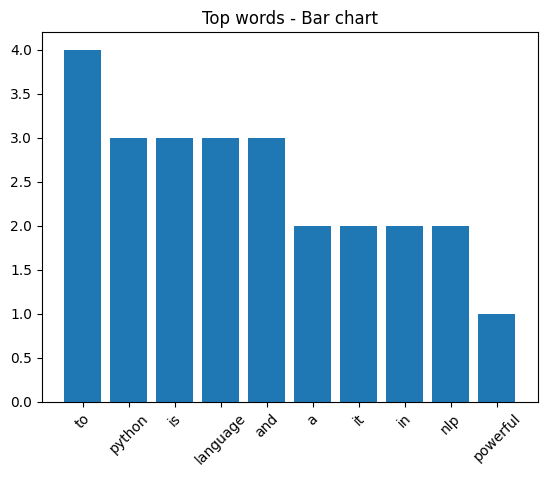

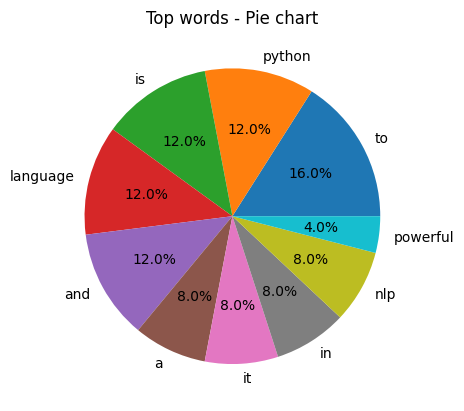

In [3]:
from collections import Counter
import matplotlib.pyplot as plt

# create input.txt automatically
with open("input.txt", "w") as f:
    f.write("Python is a powerful programming language. It is widely used in data science. Python is easy to learn. It also plays a major role in natural language processing due to its rich set of libraries like NLTK and spaCy. NLP has evolved through various generations, starting from rule based systems to statistical models and now advanced deep learning approaches. Modern NLP techniques powered by Python enable machines to understand, interpret and generate human language effectively.")

# read file
with open("input.txt", encoding="utf-8") as f:
    text = f.read()

# sentences
sentences = text.split('.')
print("a) Sentences:")
for i, s in enumerate(sentences):
    s = s.strip()
    if s:
        print(f"Sentence {i+1}: {s}")

# words in each sentence
print("\nb) Words in each sentence:")
all_words = []
for i, s in enumerate(sentences):
    words = [w.lower().strip('.,') for w in s.split()]
    if words:
        print(f"Sentence {i+1} words:", words)
        all_words.extend(words)

# word count in paragraph
print("\nc) Word count in paragraph:")
para_count = Counter(all_words)
print(dict(para_count))

# word count in each sentence
print("\nd) Word count in each sentence:")
for i, s in enumerate(sentences):
    words = [w.lower().strip('.,') for w in s.split()]
    if words:
        print(f"Sentence {i+1}:", dict(Counter(words)))

# top 10 words
print("\ne) Top 10 words:")
top = para_count.most_common(10)
words = [w for w, c in top]
counts = [c for w, c in top]
print(top)

# bar chart
plt.bar(words, counts)
plt.title("Top words - Bar chart")
plt.xticks(rotation=45)
plt.show()

# pie chart
plt.pie(counts, labels=words, autopct='%1.1f%%')
plt.title("Top words - Pie chart")
plt.show()

In [8]:
from nltk.util import ngrams

# input corpus
text = "Python is a powerful programming language. It is widely used in data science."

# preprocessing (clean + split)
words = [w.strip('.,').lower() for w in text.split()]

# i. corpus words
print("Corpus Words:")
print(words)

# ii. vocabulary
print("\nVocabulary:")
print(set(words))

# iii. unigrams
print("\nUnigrams:")
print(list(ngrams(words, 1)))

# iv. bigrams
print("\nBigrams:")
print(list(ngrams(words, 2)))

# v. n-grams (example: trigrams)
print("\nN-grams (3):")
print(list(ngrams(words, 3)))

Corpus Words:
['python', 'is', 'a', 'powerful', 'programming', 'language', 'it', 'is', 'widely', 'used', 'in', 'data', 'science']

Vocabulary:
{'used', 'science', 'widely', 'in', 'data', 'a', 'it', 'is', 'language', 'powerful', 'programming', 'python'}

Unigrams:
[('python',), ('is',), ('a',), ('powerful',), ('programming',), ('language',), ('it',), ('is',), ('widely',), ('used',), ('in',), ('data',), ('science',)]

Bigrams:
[('python', 'is'), ('is', 'a'), ('a', 'powerful'), ('powerful', 'programming'), ('programming', 'language'), ('language', 'it'), ('it', 'is'), ('is', 'widely'), ('widely', 'used'), ('used', 'in'), ('in', 'data'), ('data', 'science')]

N-grams (3):
[('python', 'is', 'a'), ('is', 'a', 'powerful'), ('a', 'powerful', 'programming'), ('powerful', 'programming', 'language'), ('programming', 'language', 'it'), ('language', 'it', 'is'), ('it', 'is', 'widely'), ('is', 'widely', 'used'), ('widely', 'used', 'in'), ('used', 'in', 'data'), ('in', 'data', 'science')]


In [9]:
from nltk.stem import PorterStemmer

# input text
text = "Python is a powerful programming language and programmers love programming"

# preprocessing
words = [w.strip('.,').lower() for w in text.split()]

# stemming
ps = PorterStemmer()

print("Original Words:")
print(words)

print("\nStemmed Words:")
print([ps.stem(w) for w in words])

Original Words:
['python', 'is', 'a', 'powerful', 'programming', 'language', 'and', 'programmers', 'love', 'programming']

Stemmed Words:
['python', 'is', 'a', 'power', 'program', 'languag', 'and', 'programm', 'love', 'program']


In [14]:
import heapq
from collections import Counter

# actual dataset
text = """I skipped my breakfast today
I ate my breakfast today
I ate my lunch yesterday
I skipped my lunch today"""

# preprocessing
words = text.lower().split()

# frequency
freq = Counter(words)

# sort for stable output (VERY IMPORTANT)
heap = [[wt, [word, ""]] for word, wt in sorted(freq.items())]
heapq.heapify(heap)

# build Huffman tree
while len(heap) > 1:
    lo = heapq.heappop(heap)
    hi = heapq.heappop(heap)

    for pair in lo[1:]:
        pair[1] = '0' + pair[1]
    for pair in hi[1:]:
        pair[1] = '1' + pair[1]

    heapq.heappush(heap, [lo[0] + hi[0]] + lo[1:] + hi[1:])

# output
print("Huffman Codes:")
for word, code in sorted(heap[0][1:]):
    print(word, ":", code, "(length =", len(code), ")")

Huffman Codes:
ate : 1101 (length = 4 )
breakfast : 1110 (length = 4 )
i : 00 (length = 2 )
lunch : 1111 (length = 4 )
my : 01 (length = 2 )
skipped : 100 (length = 3 )
today : 101 (length = 3 )
yesterday : 1100 (length = 4 )


In [19]:
# input sentences
sentences = [
    "I skipped my breakfast today",
    "I ate my breakfast today",
    "I ate my lunch yesterday",
    "I skipped my lunch today"
]

# preprocessing
words = []
for s in sentences:
    words.extend(s.lower().split())

# window size
w = 2

print("CBOW:")
for i in range(w, len(words)-w):
    context = words[i-w:i] + words[i+1:i+w+1]
    target = words[i]
    print(context, "->", target)

print("\nSkip-gram:")
for i in range(w, len(words)-w):
    target = words[i]
    context = [words[i-1], words[i+1]]
    for c in context:
        print(target, "->", c)

CBOW:
['i', 'skipped', 'breakfast', 'today'] -> my
['skipped', 'my', 'today', 'i'] -> breakfast
['my', 'breakfast', 'i', 'ate'] -> today
['breakfast', 'today', 'ate', 'my'] -> i
['today', 'i', 'my', 'breakfast'] -> ate
['i', 'ate', 'breakfast', 'today'] -> my
['ate', 'my', 'today', 'i'] -> breakfast
['my', 'breakfast', 'i', 'ate'] -> today
['breakfast', 'today', 'ate', 'my'] -> i
['today', 'i', 'my', 'lunch'] -> ate
['i', 'ate', 'lunch', 'yesterday'] -> my
['ate', 'my', 'yesterday', 'i'] -> lunch
['my', 'lunch', 'i', 'skipped'] -> yesterday
['lunch', 'yesterday', 'skipped', 'my'] -> i
['yesterday', 'i', 'my', 'lunch'] -> skipped
['i', 'skipped', 'lunch', 'today'] -> my

Skip-gram:
my -> skipped
my -> breakfast
breakfast -> my
breakfast -> today
today -> breakfast
today -> i
i -> today
i -> ate
ate -> i
ate -> my
my -> ate
my -> breakfast
breakfast -> my
breakfast -> today
today -> breakfast
today -> i
i -> today
i -> ate
ate -> i
ate -> my
my -> ate
my -> lunch
lunch -> my
lunch -> yes

In [29]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
from nltk import pos_tag

# input
sentences = [
    "I skipped my breakfast today",
    "I ate my breakfast today",
    "I ate my lunch yesterday",
    "I skipped my lunch today"
]

# -------- Statistical (SAFE) --------
print("Statistical POS Tagging:")

for s in sentences:
    words = s.split()   # no tokenizer
    print(pos_tag(words))


# -------- Rule-Based --------
print("\nRule-Based POS Tagging:")

for s in sentences:
    words = s.lower().split()
    tags = []
    
    for w in words:
        if w in ["i", "my"]:
            tag = "PRON"
        elif w in ["skipped", "ate"]:
            tag = "VERB"
        elif w in ["breakfast", "lunch"]:
            tag = "NOUN"
        elif w in ["today", "yesterday"]:
            tag = "ADV"
        else:
            tag = "NOUN"
        
        tags.append((w, tag))
    
    print(tags)

Statistical POS Tagging:
[('I', 'PRP'), ('skipped', 'VBD'), ('my', 'PRP$'), ('breakfast', 'NN'), ('today', 'NN')]
[('I', 'PRP'), ('ate', 'VBP'), ('my', 'PRP$'), ('breakfast', 'NN'), ('today', 'NN')]
[('I', 'PRP'), ('ate', 'VBP'), ('my', 'PRP$'), ('lunch', 'NN'), ('yesterday', 'NN')]
[('I', 'PRP'), ('skipped', 'VBD'), ('my', 'PRP$'), ('lunch', 'NN'), ('today', 'NN')]

Rule-Based POS Tagging:
[('i', 'PRON'), ('skipped', 'VERB'), ('my', 'PRON'), ('breakfast', 'NOUN'), ('today', 'ADV')]
[('i', 'PRON'), ('ate', 'VERB'), ('my', 'PRON'), ('breakfast', 'NOUN'), ('today', 'ADV')]
[('i', 'PRON'), ('ate', 'VERB'), ('my', 'PRON'), ('lunch', 'NOUN'), ('yesterday', 'ADV')]
[('i', 'PRON'), ('skipped', 'VERB'), ('my', 'PRON'), ('lunch', 'NOUN'), ('today', 'ADV')]


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\0018r\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\0018r\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\0018r\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\0018r\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [33]:
#pip install spacy
#python -m spacy download en_core_web_sm
import spacy
spacy.cli.download("en_core_web_sm")

# load model
nlp = spacy.load("en_core_web_sm")

# input sentences
sentences = [
    "I skipped my breakfast today.",
    "I saw a boy with a telescope."
]

print("Dependency Parsing:")

for s in sentences:
    doc = nlp(s)
    print("\nSentence:", s)
    
    for token in doc:
        print(token.text, "->", token.dep_, "->", token.head.text)

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Dependency Parsing:

Sentence: I skipped my breakfast today.
I -> nsubj -> skipped
skipped -> ROOT -> skipped
my -> poss -> breakfast
breakfast -> dobj -> skipped
today -> npadvmod -> skipped
. -> punct -> skipped

Sentence: I saw a boy with a telescope.
I -> nsubj -> saw
saw -> ROOT -> saw
a -> det -> boy
boy -> dobj -> saw
with -> prep -> saw
a -> det -> telescope
telescope -> pobj -> with
. -> punct -> saw


In [38]:
import stanza
stanza.download('en')
# load pipeline (with constituency parser)
nlp = stanza.Pipeline(lang='en', processors='tokenize,pos,constituency')

# input sentences
sentences = [
    "I skipped my breakfast today.",
    "I saw a boy with a telescope."
]

print("Constituency Parsing:")

for s in sentences:
    doc = nlp(s)
    print("\nSentence:", s)
    
    # print tree
    print(doc.sentences[0].constituency)

2026-03-22 23:45:13 INFO: Downloaded file to C:\Users\0018r\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\resources.json
2026-03-22 23:45:13 INFO: Downloading default packages for language: en (English) ...
2026-03-22 23:45:13 INFO: File exists: C:\Users\0018r\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\en\default.zip
2026-03-22 23:45:16 INFO: Finished downloading models and saved to C:\Users\0018r\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources
2026-03-22 23:45:16 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-03-22 23:45:17 INFO: Downloaded file to C:\Users\0018r\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\resources.json
2026-03-22 23:45:17 WARNING: Language en package default expects mwt, which has been added
2026-03-22 23:45:17 INFO: Loading these models for language: en (English):
| Process

Constituency Parsing:

Sentence: I skipped my breakfast today.
(ROOT (S (NP (PRP I)) (VP (VBD skipped) (NP (PRP$ my) (NN breakfast)) (NP (NN today))) (. .)))

Sentence: I saw a boy with a telescope.
(ROOT (S (NP (PRP I)) (VP (VBD saw) (NP (NP (DT a) (NN boy)) (PP (IN with) (NP (DT a) (NN telescope))))) (. .)))


In [39]:
import re

# input text (Case Study 3)
text = """Researchers from IIT Delhi and Microsoft collaborated on 15th August 2023.
They presented the model at ACL Conference in London."""

words = text.replace(".", "").split()

# -------- Rule-Based (BIO) --------
persons = ["researchers"]
orgs = ["iit", "delhi", "microsoft", "acl"]
locations = ["london"]
dates = ["15th", "august", "2023"]

print("Rule-Based NER (BIO):")

for w in words:
    wl = w.lower()
    
    if wl in persons:
        tag = "B-PER"
    elif wl in orgs:
        tag = "B-ORG"
    elif wl in locations:
        tag = "B-LOC"
    elif wl in dates:
        tag = "B-DATE"
    else:
        tag = "O"
    
    print(w, "->", tag)


# -------- Statistical (CRF-like) --------
print("\nStatistical NER (CRF-like):")

for w in words:
    
    if w.istitle():
        if w in ["IIT", "Delhi", "Microsoft", "ACL", "London"]:
            tag = "ORG/LOC"
        elif w in ["Researchers"]:
            tag = "PER"
        else:
            tag = "ENTITY"
    
    elif any(c.isdigit() for c in w):
        tag = "DATE"
    
    else:
        tag = "O"
    
    print(w, "->", tag)

Rule-Based NER (BIO):
Researchers -> B-PER
from -> O
IIT -> B-ORG
Delhi -> B-ORG
and -> O
Microsoft -> B-ORG
collaborated -> O
on -> O
15th -> B-DATE
August -> B-DATE
2023 -> B-DATE
They -> O
presented -> O
the -> O
model -> O
at -> O
ACL -> B-ORG
Conference -> O
in -> O
London -> B-LOC

Statistical NER (CRF-like):
Researchers -> PER
from -> O
IIT -> O
Delhi -> ORG/LOC
and -> O
Microsoft -> ORG/LOC
collaborated -> O
on -> O
15th -> DATE
August -> ENTITY
2023 -> DATE
They -> ENTITY
presented -> O
the -> O
model -> O
at -> O
ACL -> O
Conference -> ENTITY
in -> O
London -> ORG/LOC


In [40]:
# premise and hypothesis
premise = "I ate my breakfast today"
hypothesis = "I had breakfast"

print("Rule-Based NLI:")

p_words = set(premise.lower().split())
h_words = set(hypothesis.lower().split())

# -------- Rule-Based --------
if h_words.issubset(p_words):
    print("Entailment")
elif "not" in hypothesis.lower():
    print("Contradiction")
else:
    print("Neutral")


# -------- Word Alignment NLI --------
print("\nWord Alignment NLI:")

p_list = premise.lower().split()
h_list = hypothesis.lower().split()

aligned = 0

for w in h_list:
    if w in p_list:
        aligned += 1

# simple alignment score
if aligned == len(h_list):
    print("Entailment")
elif aligned > 0:
    print("Neutral")
else:
    print("Contradiction")

Rule-Based NLI:
Neutral

Word Alignment NLI:
Neutral


In [45]:
from textblob import TextBlob

# input paragraph
text = """The product quality is excellent and the delivery was very fast.
I am satisfied with the service and would recommend it to others."""

blob = TextBlob(text)

# sentiment
polarity = blob.sentiment.polarity

print("Polarity:", polarity)

if polarity > 0:
    print("Overall Sentiment: Positive")
elif polarity < 0:
    print("Overall Sentiment: Negative")
else:
    print("Overall Sentiment: Neutral")

Polarity: 0.5866666666666667
Overall Sentiment: Positive


In [42]:
# input sentence
text = "The movie had great visuals but the story was bad."

# word lists
positive_words = ["great", "good", "excellent"]
negative_words = ["bad", "poor", "worst"]

# preprocessing
words = text.lower().replace(".", "").split()

# count
pos = 0
neg = 0

for w in words:
    if w in positive_words:
        pos += 1
    elif w in negative_words:
        neg += 1

# output
print("Positive words:", pos)
print("Negative words:", neg)

if pos > neg:
    print("Overall Sentiment: Positive")
elif neg > pos:
    print("Overall Sentiment: Negative")
else:
    print("Overall Sentiment: Neutral")

Positive words: 1
Negative words: 1
Overall Sentiment: Neutral


In [1]:
pwd

'C:\\Users\\vendr\\OneDrive\\Desktop\\nlp'